In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report



In [2]:

# --- 1. Data Loading, Cleaning, and Preprocessing (Part 1) ---

# Load data
df = pd.read_csv("Akanksha-TRAIN.csv")

df.rename(columns={'MonthsInUnion': 'Tenure', 
                   'MonthlyDues': 'MonthlyCharges', 
                   'TotalDues': 'TotalCharges', 
                   'LeftUnion': 'Churn'}, inplace=True)

df['TotalCharges'] = df['TotalCharges'].replace(' ', np.nan)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])

df['TotalCharges'] = df['TotalCharges'].fillna(0)

df.drop('SetID', axis=1, inplace=True)

df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

categorical_features = df.select_dtypes(include='object').columns.tolist()
df_encoded = pd.get_dummies(df, columns=categorical_features, drop_first=True)

X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']


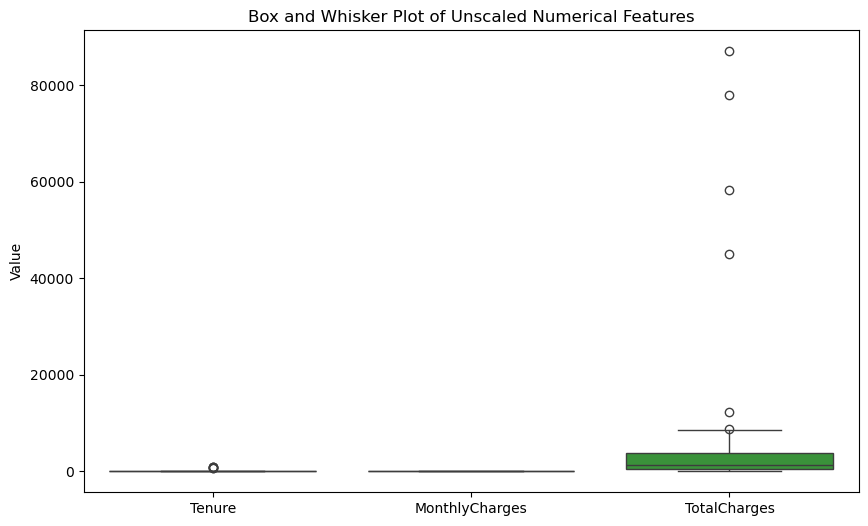

In [3]:
# --- 2. Visualization (Part 1: Box Plot) ---
numerical_features = ['Tenure', 'MonthlyCharges', 'TotalCharges']
plt.figure(figsize=(10, 6))
sns.boxplot(data=X[numerical_features])
plt.title('Box and Whisker Plot of Unscaled Numerical Features')
plt.ylabel('Value')
plt.savefig('unscaled_boxplot.png')
plt.show()

In [4]:
# --- 3. Normalization/Standardization ---
X_numeric = X.astype(int) 
scaler = StandardScaler()
X_scaled_array = scaler.fit_transform(X_numeric)
X_scaled = pd.DataFrame(X_scaled_array, columns=X.columns)

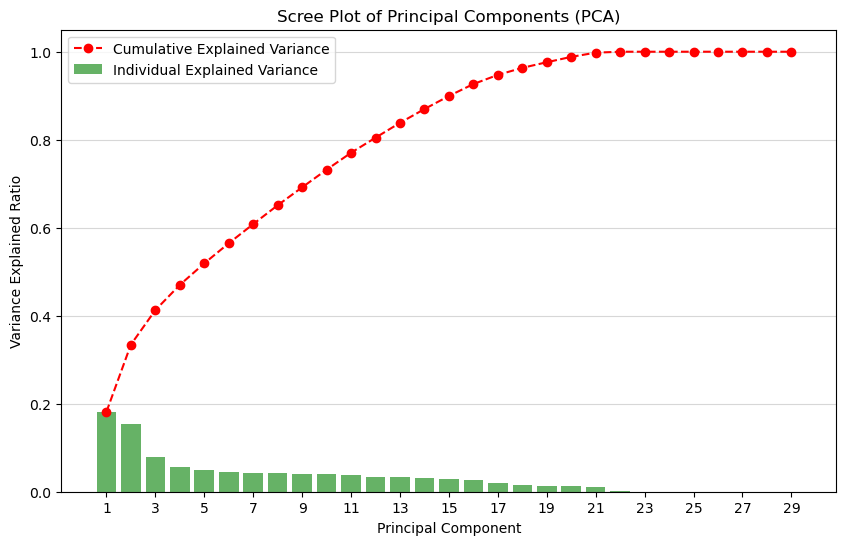

In [5]:

# --- 4. Principal Component Analysis (PCA) and Scree Plot ---
pca = PCA(n_components=X_scaled.shape[1])
pca.fit(X_scaled)
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

# Scree Plot
plt.figure(figsize=(10, 6))
plt.bar(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, alpha=0.6, color='g', label='Individual Explained Variance')
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--', color='r', label='Cumulative Explained Variance')
plt.title('Scree Plot of Principal Components (PCA)')
plt.xlabel('Principal Component')
plt.ylabel('Variance Explained Ratio')
plt.xticks(range(1, len(explained_variance_ratio) + 1, 2))
plt.grid(axis='y', alpha=0.5)
plt.legend()
plt.savefig('scree_plot.png')
plt.show()

# Transform to 2D for Scatter Plot
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)
X_pca_df = pd.DataFrame(data=X_pca_2d, columns=['PC1', 'PC2'])
X_pca_df['Churn'] = y

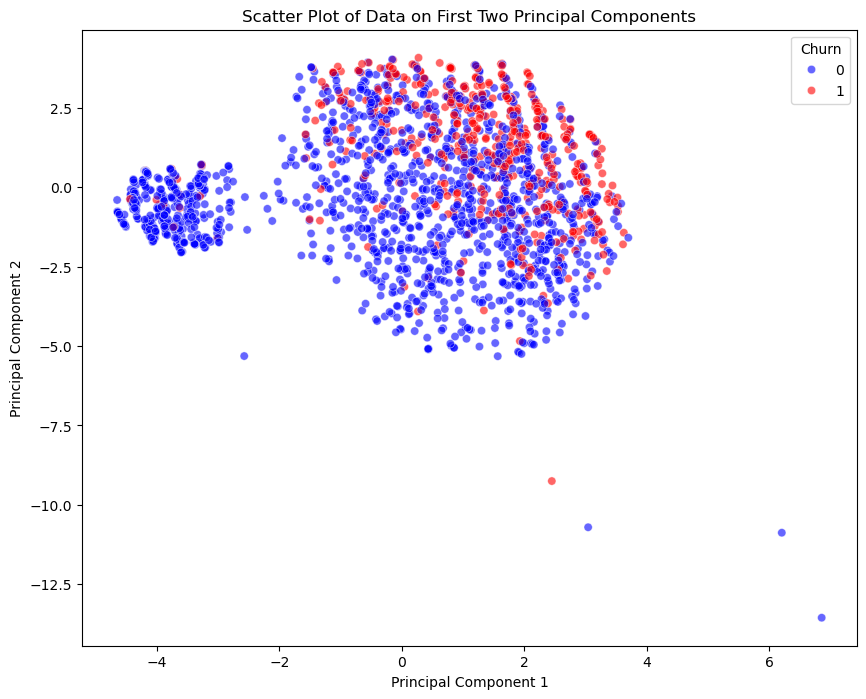

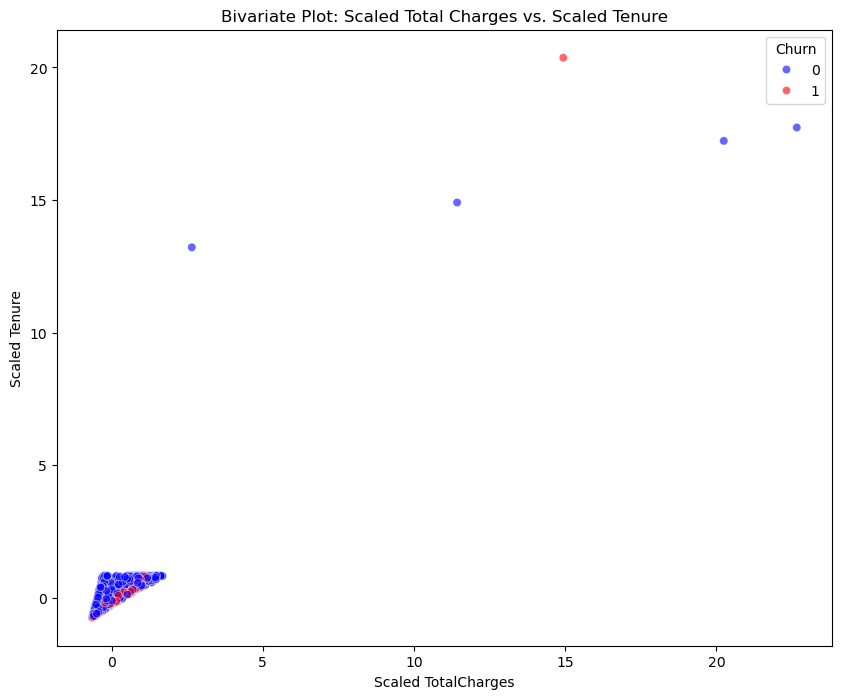

In [6]:

# --- 5. Visualization (Part 2: Scatter and Bivariate Plots) ---

# Scatter Plot (PCA Components)
plt.figure(figsize=(10, 8))
sns.scatterplot(x='PC1', y='PC2', hue='Churn', data=X_pca_df, palette=['blue', 'red'], alpha=0.6)
plt.title('Scatter Plot of Data on First Two Principal Components')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.savefig('pca_scatter_plot.png')
plt.show()

# Bivariate Plot (Tenure vs. TotalCharges) - using scaled data
df_plot = pd.concat([X_scaled[['Tenure', 'TotalCharges']], y], axis=1)
plt.figure(figsize=(10, 8))
sns.scatterplot(x='TotalCharges', y='Tenure', hue='Churn', data=df_plot, palette=['blue', 'red'], alpha=0.6)
plt.title('Bivariate Plot: Scaled Total Charges vs. Scaled Tenure')
plt.xlabel('Scaled TotalCharges')
plt.ylabel('Scaled Tenure')
plt.savefig('bivariate_plot.png')
plt.show()

In [7]:

# --- 6. Model Training and Evaluation ---
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42, stratify=y)
results = {}

# Model 1: Logistic Regression
log_model = LogisticRegression(random_state=42, solver='liblinear')
log_model.fit(X_train, y_train)
log_predictions = log_model.predict(X_test)
results['Logistic Regression'] = accuracy_score(y_test, log_predictions)

# Model 2: Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_test)
results['Random Forest'] = accuracy_score(y_test, rf_predictions)

# Model 3: Support Vector Machine (SVC)
svm_model = SVC(random_state=42)
svm_model.fit(X_train, y_train)
svm_predictions = svm_model.predict(X_test)
results['Support Vector Machine'] = accuracy_score(y_test, svm_predictions)

# Print Final Comparison
print("\n--- Model Comparison ---")
for model, acc in results.items():
    print(f"{model}: {acc:.4f}")


--- Model Comparison ---
Logistic Regression: 0.7933
Random Forest: 0.7750
Support Vector Machine: 0.7783
